**Algorithme RS (Recuit Simulé)**

Fait Par :
- Bakir Kouta 
- Timoté RICHARD


Le projet consiste à **planifier de manière optimale** un ensemble d’opérations médicales en respectant toutes les contraintes réelles (séquence, ressources limitées), afin de **minimiser le temps total** de traitement et fournir un tableau clair et exploitable pour la prise de décision.
Ici, nous utiliserons **l'algorithme du Recuit Simulé (RS)**.

In [1]:
#Importation des bibliothèques et des données
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

patients = list(range(1, 11))
skills = ["C1", "C2", "C3", "C4", "C5", "C6"]

# Les 10 patients et leurs opérations nécessitant des compétences
patient_ops = {
    1: [["C1","C1"], ["C1","C2"], ["C1","C3"], ["C1","C2","C2"], ["C4","C5","C5","C6"]],
    2: [["C2","C3"], ["C2","C3"], ["C2"], [], []],
    3: [["C3","C3"], ["C3"], [], [], []],
    4: [["C4","C4"], ["C5","C6"], ["C6","C6"], ["C4","C4"], ["C1","C2"]],
    5: [["C2","C2"], ["C5"], ["C5","C6"], ["C4","C5"], ["C3"]],
    6: [["C1"], ["C4"], ["C6"], [], []],
    7: [["C6","C6"], ["C1"], ["C5", "C6"], ["C3"], []],
    8: [["C3","C5"], ["C2","C5"], ["C3","C6"], ["C6"], []],
    9: [["C5"], ["C4"], ["C1"], [], []],
    10: [["C4"], ["C4","C5"], ["C1","C2"], ["C4"], []],
}


In [2]:
# Initialisation de la solution initiale
def solution_initiale():
    assign = {s: [] for s in skills}
    for p, ops in patient_ops.items():
        for o_idx, op_skills in enumerate(ops, start=1):
            for s in op_skills:
                assign[s].append((p, o_idx))
    # Mélange de chaque compétence pour initier le recuit 
    # On pourra utiliser ce shuffle si on ne suppose pas que l'opération n doit être réalisé avant l'opération n+1
    # le mélange sert surtout à explorer plus de solutions et éviter les minima locaux, mais si le Cmax minimal est unique, le mélange n’a pas d’effet sur le résultat final
    #for s in skills:
        #random.shuffle(assign[s])
    return assign

# Pour chaque patient, vérifier que l'ordre des opérations est respecté
def est_valide(assign):
    dernier_op = {p: 0 for p in patients}
    for s in skills:
        for p, o in assign[s]:
            if o < dernier_op[p]:
                return False  # ordre violé
            dernier_op[p] = max(dernier_op[p], o)
    return True


In [ ]:
# Mise en place de la fonction de génération de voisinage
def voisin(assign):
    s_new = {k: v.copy() for k, v in assign.items()}
    skill = random.choice(skills)
    if len(s_new[skill]) > 1:
        i, j = random.sample(range(len(s_new[skill])), 2)
        # swap seulement si cela reste valide
        s_new[skill][i], s_new[skill][j] = s_new[skill][j], s_new[skill][i]
        if not est_valide(s_new):
            s_new[skill][i], s_new[skill][j] = s_new[skill][j], s_new[skill][i]  # annuler si invalide
    return s_new


In [4]:
# Nombre de sous-tâches max sur toutes les compétences
def cout(assign):
    return max(len(v) for v in assign.values())


In [5]:
# Implémentation de l'algorithme de recuit simulé
def recuit_simule(t0=1000, alpha=0.95, t_min=0.1, iter_cycle=100):
    # On peut modifier les paramètres et analyser les différents résultats
    assign = solution_initiale()
    f = cout(assign)
    assign_best = assign
    f_best = f
    t = t0

    while t > t_min:
        for _ in range(iter_cycle):
            assign2 = voisin(assign)
            f2 = cout(assign2)
            delta = f2 - f
            if delta < 0 or random.random() < math.exp(-delta / t):
                assign = assign2
                f = f2
                if f < f_best:
                    assign_best = assign2
                    f_best = f2
        t *= alpha
    return assign_best, f_best


In [6]:
# Générer un planning sous forme de matrice
def generer_planning_slots(assign):
    planning = {s: [] for s in skills}  # liste de sous-tâches (patient, op) ou None
    time_skill = {s: 0 for s in skills}  # prochain slot libre de la machine
    time_patient = {p: 0 for p in patients}  # fin dernière opération du patient

    # copie des sous-tâches à placer
    tasks_remaining = {s: assign[s].copy() for s in skills}

    while any(tasks_remaining[s] for s in skills): # Tant qu’il reste au moins une tâche non planifiée, on continue
        for s in skills:
            if tasks_remaining[s]:
                p, o = tasks_remaining[s][0]

                # trouver le premier slot valide pour cette sous-tâche
                slot = max(time_skill[s], time_patient[p])

                # ajouter des slots vides si nécessaire
                while len(planning[s]) < slot:
                    planning[s].append(None)

                # placer la sous-tâche
                planning[s].append((p, o))

                # mettre à jour les temps
                time_skill[s] = slot + 1
                time_patient[p] = slot + 1

                # retirer la tâche placée
                tasks_remaining[s].pop(0)

    return planning


In [7]:
# Visualisation
def afficher_planning_slots(planning):
    colors = plt.cm.tab10(np.linspace(0,1,10)) # 10 couleurs distinctes (une par patient)
    max_len = max(len(v) for v in planning.values())
    fig, ax = plt.subplots(figsize=(1.2*max_len,4))
    
    for i, skill in enumerate(skills):
        for j in range(max_len):
            if j < len(planning[skill]):
                task = planning[skill][j]
                if task is None:
                    rect = plt.Rectangle((j,i),1,1,facecolor='white',edgecolor='black')
                    ax.add_patch(rect)
                else:
                    p, o = task
                    # On crée un rectangle coloré avec la couleur du patient p
                    rect = plt.Rectangle((j,i),1,1,facecolor=colors[p-1],edgecolor='black')
                    ax.add_patch(rect)
                    # On affiche le numéro de l’opération o au centre du rectangle.
                    ax.text(j+0.5,i+0.5,str(o),ha='center',va='center',color='white',fontsize=12,fontweight='bold')
            else:
                #compléter avec slot vide si la ligne est plus courte
                rect = plt.Rectangle((j,i),1,1,facecolor='white',edgecolor='black')
                ax.add_patch(rect)
    
    ax.set_yticks(np.arange(len(skills))+0.5)
    ax.set_yticklabels(skills)
    ax.set_xticks(range(max_len))
    ax.set_xlabel("Temps")
    ax.set_ylabel("Compétences")
    
    legend_patches = [mpatches.Patch(color=colors[i], label=f"Patient {i+1}") for i in range(10)]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', title="Patients")
    
    plt.gca().invert_yaxis()
    plt.title("Planning optimisé")
    plt.tight_layout()
    plt.show()


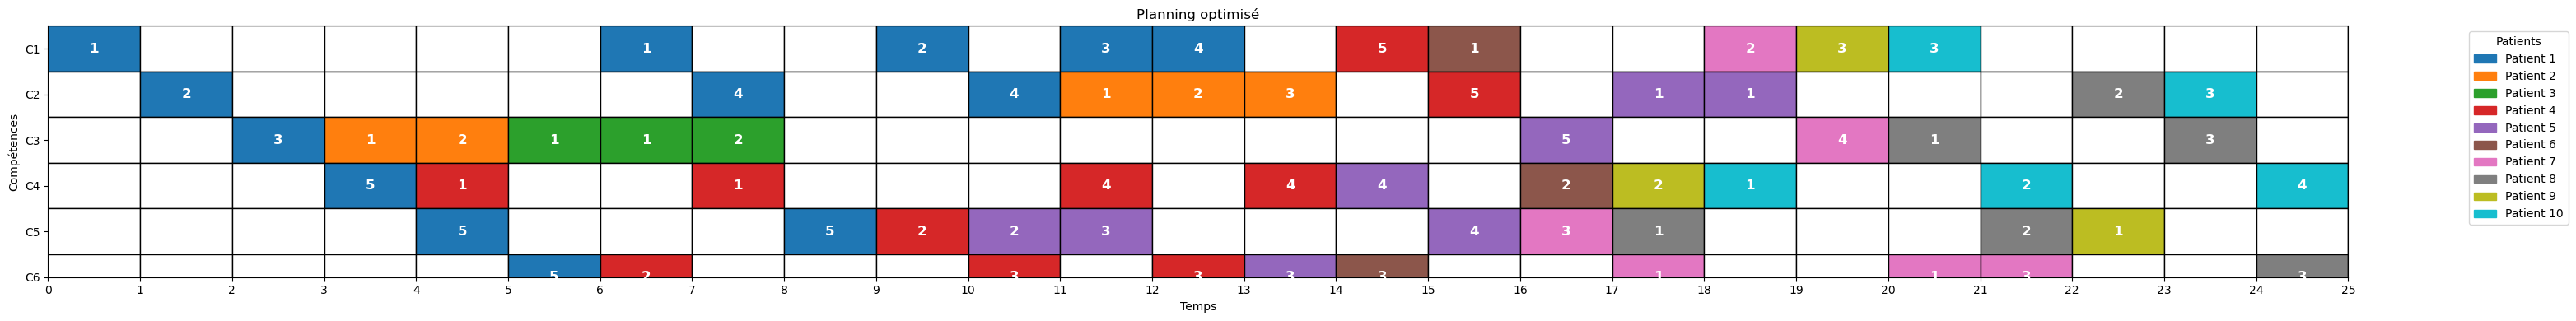

In [8]:
# Résultat
# Générer une solution initiale
assign = solution_initiale()

# Générer le planning et l'afficher
planning_slots = generer_planning_slots(assign)
afficher_planning_slots(planning_slots)


In [9]:
# Calcul du coût
def cout_slots(planning):
    # longueur maximale de toutes les lignes (compétences)
    max_len = max(len(v) for v in planning.values())
    return max_len

assign = solution_initiale()
planning_slots = generer_planning_slots(assign)
f = cout_slots(planning_slots)
print(f"Makespan total : {f}")


Makespan total : 26


Pour avoir la meilleure solution, on lance l'algorithme de recuit simulé plusieurs fois, et on garde la meilleure solution globale parmi toutes.

Meilleure solution trouvée :
cMAX = 11


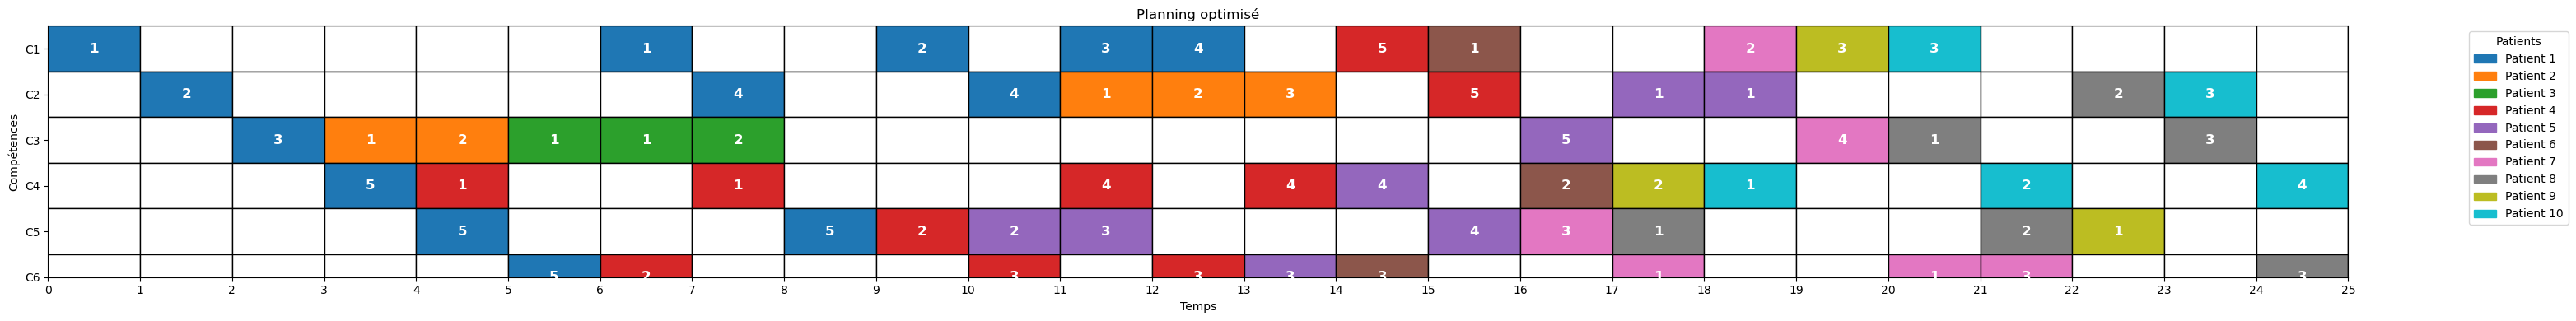

In [10]:
best_overall = None
cmax_best = float('inf')

for i in range(20):  # 20 exécutions différentes
    assign_opt, f_opt = recuit_simule()
    if f_opt < cmax_best:
        cmax_best = f_opt
        best_overall = assign_opt

print("Meilleure solution trouvée :")
print(f"cMAX = {cmax_best}")
planning_slots = generer_planning_slots(best_overall)
afficher_planning_slots(planning_slots)


Pour résoudre ce problème complexe d’ordonnancement, nous avons utilisé un **algorithme de recuit simulé**.
Le résultat final est un planning optimisé minimisant le temps total d’exécution des opérations (le makespan), visualisé sous forme d’un diagramme de Gantt coloré, où chaque ligne représente une compétence et chaque couleur un patient.

L’algorithme a permis d’atteindre un makespan minimal de **11 unités de temps**, illustrant l’efficacité du recuit simulé pour organiser les opérations tout en respectant les contraintes de dépendances entre les étapes de chaque patient et les capacités des compétences.

Plusieurs améliorations pourraient être envisagées pour rendre le projet encore plus performant et adaptable. Tout d'abord, nous n'avons pas réussi à optimiser le diagramme de Gantt et trop de cases restent vides ce qui peut rendre le planning moins lisible.
Mais aussi :
    - Rendre l’algorithme plus intelligent :
    - Ajouter des heuristiques de priorité pour les opérations critiques ou les compétences très sollicitées.
    - Ajouter une fonction permettant de générer aléatoirement le nombre de patients, le nombre d’opérations et les compétences associées, afin que le programme puisse s’adapter à différents scénarios.

Ces options futures permettraient de rendre le système non seulement plus *robuste* et *efficace*, mais aussi *flexible* et *capable de s’adapter* à différents contextes et tailles de problèmes.